**Notes on Python virtual environment**

To activate the virtual environment, fix Windows bug then activate:
1. `Set-ExecutionPolicy Unrestricted -Scope Process`
2. `.venv\Scripts\activate`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from simplex_projection import euclidean_proj_simplex
from algorithms import alg_pdtr, alg_midas
import nashpy
import pickle

In [4]:
# Matrix game
N = 10
xd = 8
yd = 8
for rep in range(5):
    rng_gen = np.random.default_rng(int(f'2025{rep}'))
    K = rng_gen.uniform(low=0, high=1, size=(N, yd, xd))
    for ii in range(N):
        s_i = 1.1*np.linalg.norm(K[ii], ord=2)
        K[ii] = (ii+1)*(s_i*np.eye(xd) - K[ii])   # K_i = i(s_i I - M_i), where M_i~U(0,1), i=1,...,N

    with open(f'matrix_data_x{xd}_y{yd}_rep{rep}', 'wb') as f:
        pickle.dump(K, f)

    fullK = np.sum(K, axis=0)
    rps = nashpy.Game(fullK)
    eqs = rps.vertex_enumeration()
    zsol = np.hstack(list(eqs)[0][::-1])

    with open(f'matrix_sol_x{xd}_y{yd}_rep{rep}', 'wb') as f:
        pickle.dump(zsol, f)

# print(zsol)

In [4]:
# Lipschitz constants
L = np.linalg.norm(K, ord=2, axis=(1,2))
L_scaled = L/max(L)
L_entropy = -np.sum(L_scaled*np.log(L_scaled))
print('Synthetic:')
print(f'Norm. range = {max(L_scaled)-min(L_scaled)}')
print(f'Shannon entropy = {L_entropy}')

Synthetic:
Norm. range = 0.8956984119164808
Shannon entropy = 2.4636964594623487


In [31]:
# Operators
def JA(z, tau, data=None):
    r"""
    Compute resolvent J_\mathbf{A}(z) = (J_A1(z1), ..., J_AN(zN))
    :param z: (N, xd+yd) array
    :param tau: step size. Not used, included for compatibility with algorithms.py
    :param data: not used, included for compatibility with algorithms.py
    """
    JAz = z.copy()  # np.zeros_like(z)

    for ii in range(N):
        xi, yi = np.array(z[ii, :xd]), np.array(z[ii, xd:])

        # Project x and y components onto unit simplex
        JAz[ii, :xd] = euclidean_proj_simplex(np.squeeze(xi))
        JAz[ii, xd:] = euclidean_proj_simplex(np.squeeze(yi))

    return JAz

def B(z, data=None):
    r"""
    Evaulate operator \mathbf{B}(z) = (B1(z1), ..., BN(zN)).
    :param z: (N, xd+yd) array
    :param data: not used, included for compatibility with algorithms.py
    """

    Bz = np.zeros_like(z)
    for ii in range(N):
        # Extract and reshape x^+, x^- and y^+, y^- components
        xi, yi = np.array(z[ii, :xd]), np.array(z[ii, xd:])

        # Compute Bz for x and y components, agent i's own variables
        Bz[ii, :xd] = K[ii].T @ yi
        Bz[ii, xd:] = -xi @ K[ii].T
    return Bz

In [32]:
# Performance metrics
def residue(x, y, tau):
    """ Distance between iterates """
    if isinstance(tau, float):
        return np.linalg.norm(x - y)/tau
    elif isinstance(tau, np.ndarray):
        tauinvsqrt = np.divide(1, np.sqrt(tau), where=(tau!=0))
        return  np.linalg.norm(tauinvsqrt @(x - y))

def epserror(z, x, tau, data=None):
    r"""
    0 \approx\in (A+B)(x) <--> tau^{-1} * (z - x) + B(x) \approx 0
    :param x: output of JA(z)
    :param tau: float or (N, N) array
    :param data: not used, included for compatibility with algorithms.py
    """
    if isinstance(tau, float):
        Ax1 = (z - x)/tau
    else:   # if step size is a matrix
        Ax1 = np.linalg.inv(tau) @ (z - x)

    return np.linalg.norm(Ax1 + B(x))

def relerror(z):
    """ Distance from reference solution to agents' iterate """
    return np.linalg.norm(z - zsol)/np.linalg.norm(zsol) # broadcasting zsol

In [33]:
# Algorithm parameters
G = nx.cycle_graph(N)
Lap = nx.laplacian_matrix(G).todense()  # Laplacian
alpha = 0.505 * np.max(np.linalg.eigvalsh(Lap))    # alpha satisfies (1/2) * lambda_max(Lap) < alpha <= (2/3) * lambda_max(Lap)
W = np.eye(N) - Lap / alpha

L = np.linalg.norm(K, ord=2, axis=(1, 2))   # Lipschitz constants for B_i -> operator norm of K_i
tau_m = 0.9 * np.diag(1/(8 * L))
tau_m_same = 0.9/8/max(L)*np.eye(N)
tau_p = 0.9 * (1 + np.min(np.linalg.eigvalsh(W))) / (4 * max(L))

betamax = 0.9/np.max(tau_m)
betanorm = 0.9/np.linalg.norm(np.sqrt(tau_m)@((np.eye(N)-W)/2)@np.sqrt(tau_m), ord=2)    # \beta = 1/||tau^(1/2)*((I-W)/2)*tau^(1/2))||

In [34]:
# Run algorithms
maxit = 10000
z0 = rng_gen.random((N, xd+yd))
z0 *= 10/np.linalg.norm(z0)    # Generate random starting point with norm 2
xs1,rel1,res1, time1 = alg_midas(z0, JA, B, W, tau_m, residue, relerror, max_iters=maxit, beta=betamax)
print('')
xs1b, rel1b, res1b, time1b = alg_midas(z0, JA, B, W, tau_m, residue, relerror, max_iters=maxit, beta=betanorm)
print('')
xs1c, rel1c, res1c, time1c = alg_midas(z0, JA, B, W, tau_m_same, residue, relerror, max_iters=maxit, beta=betamax)
print('')
xs2, rel2, res2, time2 = alg_pdtr(z0, JA, B, W, tau_p, residue, relerror, max_iters=maxit)

MIDAS: iteration 10000 of 10000
MIDAS: iteration 10000 of 10000
MIDAS: iteration 10000 of 10000


In [35]:
xs1_x, xs1_y = xs1b[0,:xd], xs1b[0,xd:]
xs2_x, xs2_y = xs2[0,:xd], xs2[0,xd:]

print('MIDAS:', xs1_x, xs1_y)
print('PDTR:', xs2_x, xs2_y)

# Nash equilibrium if (True, True), sufficient maybe not necessary
print(f'x1 is best response: {rps.is_best_response(xs1_y, xs1_x)}')
print(f'x2 is best response: {rps.is_best_response(xs2_y, xs2_x)}')

MIDAS: [0.12436836 0.1260402  0.1235642  0.12454849 0.12300438 0.12664292
 0.12573975 0.1260917 ] [0.12251322 0.12410519 0.12692366 0.12416557 0.12725642 0.12412971
 0.12536871 0.12553752]
PDTR: [0.14660841 0.13343777 0.15355351 0.07973656 0.1970356  0.10364545
 0.12524205 0.06074066] [0.09109894 0.15039925 0.13271037 0.1807479  0.17955112 0.04934061
 0.11703353 0.09911827]
x1 is best response: (False, False)
x2 is best response: (False, False)


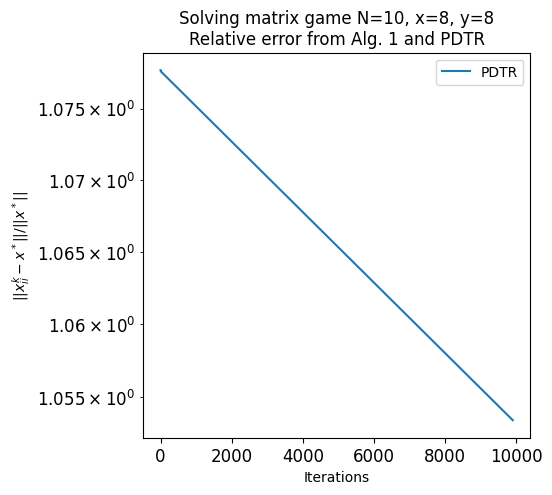

In [ ]:
# Plot relative error
fig_rel = plt.figure(figsize=(5, 5))
ax_rel = fig_rel.add_subplot(111)
ax_rel.semilogy(rel1, label=r'MIDAS, $\beta=1/max(\alpha_i)$')
ax_rel.semilogy(rel1b, label=r'MIDAS, $\beta=1/\|\Lambda^{1/2}(\frac{I-W}{2})\Lambda^{1/2})\|$')
ax_rel.semilogy(rel1c, label=r'MIDAS, $\alpha_i==\alpha$')
ax_rel.semilogy(rel2, label='PDTR')
ax_rel.set_xlabel("Iterations")
ax_rel.set_ylabel("$||x^k_{ii}-x^*||/||x^*||$")
ax_rel.set_title(f"Solving matrix game N={N}, x={xd}, y={yd}\nRelative error from Alg. 1 and PDTR")
ax_rel.tick_params(axis='both', which='both', labelsize=12)
# ax_rel.text(0.5, 0.5, L, transform=ax_rel.transAxes, wrap=True)
ax_rel.legend()
plt.savefig(f'matrixcomparison_relerror_{maxit}iters_tau05.png')

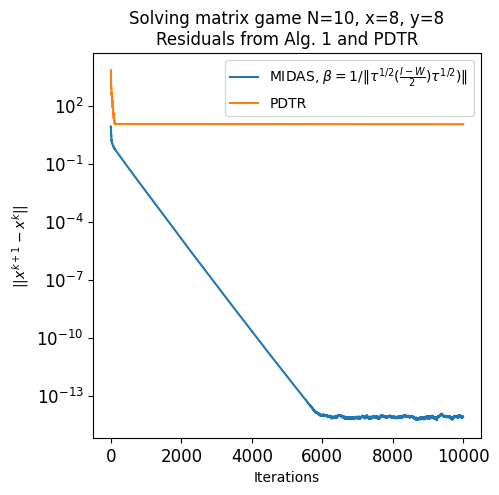

In [28]:
# ------ Residuals plot ----------
fig_res = plt.figure(figsize=(5, 5))
ax_res = fig_res.add_subplot(111)
# ax_res.semilogy(res1[1:], label=r'MIDAS, $\beta=1/max(\tau_i)$')
ax_res.semilogy(res1b[1:], label=r'MIDAS, $\beta=1/\|\tau^{1/2}(\frac{I-W}{2})\tau^{1/2})\|$')
ax_res.semilogy(res2[1:], label='PDTR')
ax_res.set_xlabel("Iterations")
ax_res.set_ylabel("$||x^{k+1}-x^k||$")
ax_res.set_title(f"Solving matrix game N={N}, x={xd}, y={yd}\nResiduals from Alg. 1 and PDTR")
ax_res.tick_params(axis='both', which='both', labelsize=12)
# ax_res.text(0.5, 0.5, L, transform=ax_res.transAxes, wrap=True)
ax_res.legend()
plt.savefig(f'matrixcomparison_resid_{maxit}iters_tau05.png')